# CMSE 402: Data Visualization Principles and Techniques
## Lowell Monis
## Spring 2025 - Dr. Devin Silvia

***
### Pre-Class Assignment (Day 5 - January 28, 2025)

#### Part 1: Types of visualization

Here are the broad categories of visualizations I found:

1. Length/Height type: https://datavizcatalogue.com/methods/images/top_images/span_chart.png. I have attached a link to a span chart. This looks convenient to convey values on a time scale, like a timeline.
2. Position type: https://matplotlib.org/stable/_images/sphx_glr_fill_between_demo_002.png. I have attached a link to a regular scatter plot with a smooth layer between the error range of the line of best fit. Best for two different types of values, where one of them is not time.
3. Area type: https://datavizcatalogue.com/methods/images/top_images/SVG/heatmap.svg. This is a heatmap that leverages area to demonstrate what I believe is the abundance of a data type. An example can be, say, high or low average temperatures of towns over time.
4. Angle/area type: https://matplotlib.org/stable/_images/sphx_glr_polar_bar_001.png. I have attached a different type of pie chart that combines a bar plot in it. The visualization design is often used to compare multivariate data sets. Say, we can visualize the number of college students (raw number so polar axis) divided by degree type (polar divisions).

#### Part 2: Statistical visualization

While I was unable to cover this reading in great detail, the gist of these chapters were essentially descriptive statistics, statistical functions, and how to visualize these statistical concepts, from frequency plots to bell curves.

In [7]:
import pandas as pd
congress = pd.read_csv('congress-terms.csv')
congress.head()

,congress,chamber,bioguide,firstname,middlename,lastname,suffix,birthday,state,party,incumbent,termstart,age
0,80,house,M000112,Joseph,Jefferson,Mansfield,NaN,1861-02-09,TX,D,Yes,1947-01-03,85.9
1,80,house,D000448,Robert,Lee,Doughton,NaN,1863-11-07,NC,D,Yes,1947-01-03,83.2
2,80,house,S000001,Adolph,Joachim,Sabath,NaN,1866-04-04,IL,D,Yes,1947-01-03,80.7
3,80,house,E000023,Charles,Aubrey,Eaton,NaN,1868-03-29,NJ,R,Yes,1947-01-03,78.8
4,80,house,L000296,William,NaN,Lewis,NaN,1868-09-22,KY,R,No,1947-01-03,78.3


([<matplotlib.patches.Wedge at 0x7f4b5d71dd90>,
 [Text(1.0946182263203266, 0.10867814227038719, '25-35'),
  Text(0.7377417566713201, 0.8159271416391998, '35-45'),
  Text(-0.8961980588408713, 0.6378315132774911, '45-55'),
  Text(-0.2546029637554773, -1.0701295860067261, '55-65'),
  Text(0.9489755749515807, -0.5562781302058504, '65-75'),
  Text(1.0963854258133967, -0.08910105534715679, '75+')])

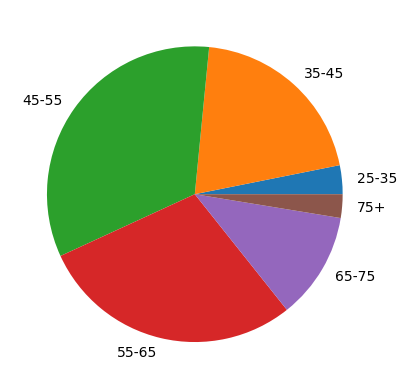

In [14]:
import matplotlib.pyplot as plt

data = {'25-35':0, '35-45':0, '45-55':0, '55-65':0, '65-75':0, '75+':0}
for i in congress['age']:
    if 25<=i<35:
        data['25-35'] +=1
    elif 35<=i<45:
        data['35-45'] +=1
    elif 45<=i<55:
        data['45-55'] +=1
    elif 55<=i<65:
        data['55-65'] +=1
    elif 65<=i<75:
        data['65-75'] +=1
    else:
        data['75+'] +=1

labels = data.keys()
values = data.values()
fig, ax = plt.subplots()
ax.pie(values, labels=labels)

/tmp/ipykernel_5403/3581438175.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dem_counts = congress[congress['party'] == 'D'].groupby('age_range').size()
/tmp/ipykernel_5403/3581438175.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rep_counts = congress[congress['party'] == 'R'].groupby('age_range').size()


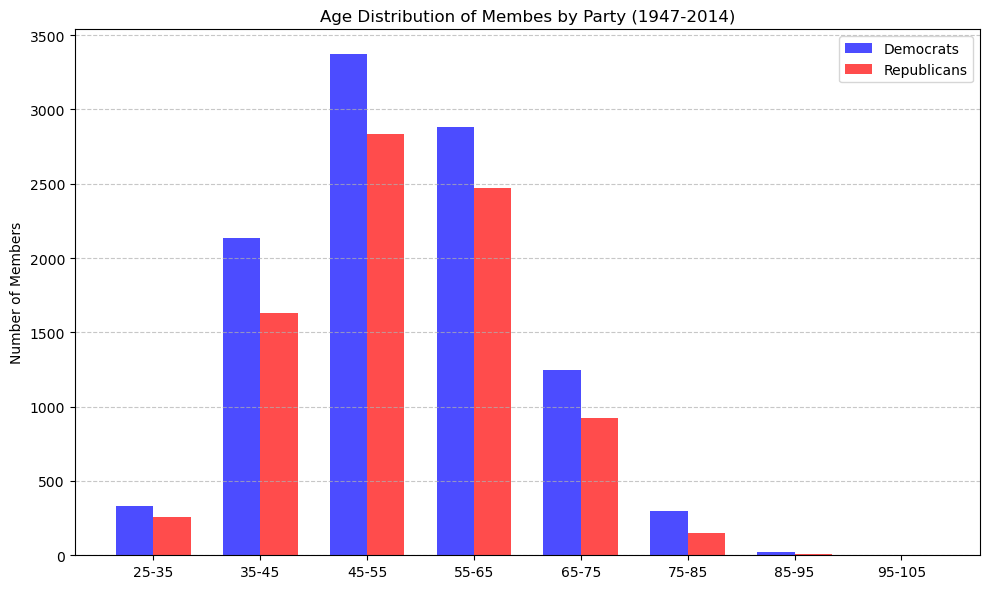

In [20]:
import numpy as np

labels = ['25-35', '35-45', '45-55', '55-65', '65-75', '75-85', '85-95', '95-105']
bins = [25, 35, 45, 55, 65, 75, 85, 95, 105]
congress['age_range'] = pd.cut(congress['age'], bins=bins, labels=labels, right=False)

dem_counts = congress[congress['party'] == 'D'].groupby('age_range').size()
rep_counts = congress[congress['party'] == 'R'].groupby('age_range').size()

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, dem_counts, width, label='Democrats', color='blue', alpha=0.7)
ax.bar(x + width/2, rep_counts, width, label='Republicans', color='red', alpha=0.7)

ax.set_ylabel('Number of Members')
ax.set_title('Age Distribution of Membes by Party (1947-2014)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()